# Classification 


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

In [2]:
from pathlib import Path

# Works whether the notebook runs from project root or notebooks/
candidate_roots = [Path.cwd(), Path.cwd().parent]
project_root = next(
    (p for p in candidate_roots if (p / "data" / "processed").exists()),
    Path.cwd()
 )
processed_dir = project_root / "data" / "processed"

news_df = pd.read_csv(processed_dir / "news_preprocessed.csv")
emails_df = pd.read_csv(processed_dir / "emails_preprocessed.csv")
contracts_df = pd.read_csv(processed_dir / "contracts_preprocessed.csv")
invoices_df = pd.read_csv(processed_dir / "invoices_preprocessed.csv")

full_df = pd.read_csv(processed_dir / "full_dataset_preprocessed.csv")

class imbalance

In [3]:
class_counts = full_df["doc_type"].value_counts()
class_counts

doc_type
email       15495
news         2123
invoice       564
contract      494
Name: count, dtype: int64

In [4]:
(class_counts / len(full_df) * 100).round(2)

doc_type
email       82.97
news        11.37
invoice      3.02
contract     2.65
Name: count, dtype: float64

We need to decide the dataset for training. for the baseline use full dataset and later compare with downsampled emails and class weighted models

In [5]:
df_model = full_df.copy()
df_model.shape

(18676, 2)

In [6]:
import sys
sys.path.insert(0, str(project_root))
from src.preprocessing import clean_for_classifier

# Apply the same clean_for_classifier used at inference time so that the
# invoice indicator tokens (__inv_header__, __bill_to__, etc.) appear in the
# training vocabulary and get assigned meaningful TF-IDF weights.
X = df_model["text"].apply(clean_for_classifier)
y = df_model["doc_type"]
print(f"Sample cleaned invoice text:\n{X[y == 'invoice'].iloc[0][:300]}")

Sample cleaned invoice text:
__inv_number__ __inv_header__ __bill_to__ __amount_due__ __due_date__ cream and white simple minimalist catering services invoice invoice borcelle | catering services description qty total total $1000 issued to: amount due $550 invoice no: #612345 unit price bank details grilled chicken 2 $200 brusc


In [7]:
# Synthetic augmentation removed — real English invoice data is now merged
# in 03_preprocessing.ipynb from data/raw/invoices/converted_invoice_dataset.csv
# so invoices_preprocessed.csv already contains both SROIE + English invoices.


## split

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [9]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [10]:
print("Train:", X_train.shape[0])
print("Validation:", X_val.shape[0])
print("Test:", X_test.shape[0])

Train: 13073
Validation: 2801
Test: 2802


In [11]:
print("\nTrain distribution:")
print(y_train.value_counts())

print("\nValidation distribution:")
print(y_val.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())


Train distribution:
doc_type
email       10846
news         1486
invoice       395
contract      346
Name: count, dtype: int64

Validation distribution:
doc_type
email       2324
news         318
invoice       85
contract      74
Name: count, dtype: int64

Test distribution:
doc_type
email       2325
news         319
invoice       84
contract      74
Name: count, dtype: int64


## Vectorize text with tf-idf

In [12]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_features=20000
)

In [13]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

In [14]:
# Duplicate TF-IDF fit removed — vectorizer is fitted once in the cell above.


In [15]:
print("X_train_tfidf:", X_train_tfidf.shape)
print("X_val_tfidf:", X_val_tfidf.shape)
print("X_test_tfidf:", X_test_tfidf.shape)

X_train_tfidf: (13073, 20000)
X_val_tfidf: (2801, 20000)
X_test_tfidf: (2802, 20000)


## Multinomial Naive Bayes

In [16]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_val_pred_nb = nb_model.predict(X_val_tfidf)
y_test_pred_nb = nb_model.predict(X_test_tfidf)

In [17]:
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_nb))
print("Validation Macro F1:", f1_score(y_val, y_val_pred_nb, average="macro"))
print("Validation Weighted F1:", f1_score(y_val, y_val_pred_nb, average="weighted"))

Validation Accuracy: 0.9957158157800785
Validation Macro F1: 0.9835069017933914
Validation Weighted F1: 0.9956405168307019


In [18]:
print(classification_report(y_val, y_val_pred_nb))

              precision    recall  f1-score   support

    contract       1.00      0.89      0.94        74
       email       1.00      1.00      1.00      2324
     invoice       1.00      1.00      1.00        85
        news       0.99      1.00      0.99       318

    accuracy                           1.00      2801
   macro avg       1.00      0.97      0.98      2801
weighted avg       1.00      1.00      1.00      2801



In [19]:
val_cm_nb = pd.DataFrame(
    confusion_matrix(y_val, y_val_pred_nb, labels=nb_model.classes_),
    index=nb_model.classes_,
    columns=nb_model.classes_
)
val_cm_nb

,contract,email,invoice,news
contract,66,8,0,0
email,0,2320,0,4
invoice,0,0,85,0
news,0,0,0,318


In [20]:
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_nb))
print("Test Macro F1:", f1_score(y_test, y_test_pred_nb, average="macro"))
print("Test Weighted F1:", f1_score(y_test, y_test_pred_nb, average="weighted"))

Test Accuracy: 0.9953604568165596
Test Macro F1: 0.9842139364880431
Test Weighted F1: 0.9953061308509268


In [21]:
print(classification_report(y_test, y_test_pred_nb))

              precision    recall  f1-score   support

    contract       1.00      0.91      0.95        74
       email       1.00      1.00      1.00      2325
     invoice       1.00      1.00      1.00        84
        news       0.98      0.99      0.99       319

    accuracy                           1.00      2802
   macro avg       1.00      0.97      0.98      2802
weighted avg       1.00      1.00      1.00      2802



In [22]:
test_cm_nb = pd.DataFrame(
    confusion_matrix(y_test, y_test_pred_nb, labels=nb_model.classes_),
    index=nb_model.classes_,
    columns=nb_model.classes_
)
test_cm_nb

,contract,email,invoice,news
contract,67,6,0,1
email,0,2321,0,4
invoice,0,0,84,0
news,0,2,0,317


In [23]:
nb_results = pd.DataFrame({
    "model": ["Multinomial Naive Bayes"],
    "val_accuracy": [accuracy_score(y_val, y_val_pred_nb)],
    "val_macro_f1": [f1_score(y_val, y_val_pred_nb, average="macro")],
    "val_weighted_f1": [f1_score(y_val, y_val_pred_nb, average="weighted")],
    "test_accuracy": [accuracy_score(y_test, y_test_pred_nb)],
    "test_macro_f1": [f1_score(y_test, y_test_pred_nb, average="macro")],
    "test_weighted_f1": [f1_score(y_test, y_test_pred_nb, average="weighted")]
})
nb_results

,model,val_accuracy,val_macro_f1,val_weighted_f1,test_accuracy,test_macro_f1,test_weighted_f1
0,Multinomial Naive Bayes,0.995716,0.983507,0.995641,0.99536,0.984214,0.995306


## Linear SVM

In [24]:
svm_model = LinearSVC(random_state=42, class_weight='balanced')
svm_model.fit(X_train_tfidf, y_train)


,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

In [25]:
y_val_pred_svm = svm_model.predict(X_val_tfidf)
y_test_pred_svm = svm_model.predict(X_test_tfidf)

In [26]:
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_svm))
print("Validation Macro F1:", f1_score(y_val, y_val_pred_svm, average="macro"))
print("Validation Weighted F1:", f1_score(y_val, y_val_pred_svm, average="weighted"))

Validation Accuracy: 0.9992859692966798
Validation Macro F1: 0.9977992818999704
Validation Weighted F1: 0.9992850351905792


In [27]:
print(classification_report(y_val, y_val_pred_svm))

              precision    recall  f1-score   support

    contract       1.00      0.99      0.99        74
       email       1.00      1.00      1.00      2324
     invoice       1.00      1.00      1.00        85
        news       1.00      1.00      1.00       318

    accuracy                           1.00      2801
   macro avg       1.00      1.00      1.00      2801
weighted avg       1.00      1.00      1.00      2801



In [28]:
val_cm_svm = pd.DataFrame(
    confusion_matrix(y_val, y_val_pred_svm, labels=svm_model.classes_),
    index=svm_model.classes_,
    columns=svm_model.classes_
)
val_cm_svm

,contract,email,invoice,news
contract,73,1,0,0
email,0,2323,0,1
invoice,0,0,85,0
news,0,0,0,318


In [29]:
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_svm))
print("Test Macro F1:", f1_score(y_test, y_test_pred_svm, average="macro"))
print("Test Weighted F1:", f1_score(y_test, y_test_pred_svm, average="weighted"))

Test Accuracy: 0.9985724482512491
Test Macro F1: 0.9952865876853014
Test Weighted F1: 0.9985731708664556


In [30]:
print(classification_report(y_test, y_test_pred_svm))

              precision    recall  f1-score   support

    contract       0.99      0.99      0.99        74
       email       1.00      1.00      1.00      2325
     invoice       1.00      1.00      1.00        84
        news       0.99      1.00      1.00       319

    accuracy                           1.00      2802
   macro avg       0.99      1.00      1.00      2802
weighted avg       1.00      1.00      1.00      2802



In [31]:
test_cm_svm = pd.DataFrame(
    confusion_matrix(y_test, y_test_pred_svm, labels=svm_model.classes_),
    index=svm_model.classes_,
    columns=svm_model.classes_
)
test_cm_svm

,contract,email,invoice,news
contract,73,0,0,1
email,1,2323,0,1
invoice,0,0,84,0
news,0,1,0,318


In [32]:
svm_results = pd.DataFrame({
    "model": ["Linear SVM (balanced)"],
    "val_accuracy": [accuracy_score(y_val, y_val_pred_svm)],
    "val_macro_f1": [f1_score(y_val, y_val_pred_svm, average="macro")],
    "val_weighted_f1": [f1_score(y_val, y_val_pred_svm, average="weighted")],
    "test_accuracy": [accuracy_score(y_test, y_test_pred_svm)],
    "test_macro_f1": [f1_score(y_test, y_test_pred_svm, average="macro")],
    "test_weighted_f1": [f1_score(y_test, y_test_pred_svm, average="weighted")]
})

pd.concat([nb_results, svm_results], ignore_index=True)

,model,val_accuracy,val_macro_f1,val_weighted_f1,test_accuracy,test_macro_f1,test_weighted_f1
0,Multinomial Naive Bayes,0.995716,0.983507,0.995641,0.995360,0.984214,0.995306
1,Linear SVM (balanced),0.999286,0.997799,0.999285,0.998572,0.995287,0.998573


## Logistic regression

In [33]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',   # compensates for email-heavy imbalance
)

lr_model.fit(X_train_tfidf, y_train)

/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [34]:
y_val_pred_lr = lr_model.predict(X_val_tfidf)
y_test_pred_lr = lr_model.predict(X_test_tfidf)

In [35]:
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_lr))
print("Validation Macro F1:", f1_score(y_val, y_val_pred_lr, average="macro"))
print("Validation Weighted F1:", f1_score(y_val, y_val_pred_lr, average="weighted"))

Validation Accuracy: 0.9978579078900393
Validation Macro F1: 0.9934697366168117
Validation Weighted F1: 0.9978630936766464


In [36]:
print(classification_report(y_val, y_val_pred_lr))

              precision    recall  f1-score   support

    contract       0.97      0.99      0.98        74
       email       1.00      1.00      1.00      2324
     invoice       1.00      1.00      1.00        85
        news       0.99      1.00      1.00       318

    accuracy                           1.00      2801
   macro avg       0.99      1.00      0.99      2801
weighted avg       1.00      1.00      1.00      2801



In [37]:
val_cm_lr = pd.DataFrame(
    confusion_matrix(y_val, y_val_pred_lr, labels=lr_model.classes_),
    index=lr_model.classes_,
    columns=lr_model.classes_
)
val_cm_lr

,contract,email,invoice,news
contract,73,1,0,0
email,2,2319,0,3
invoice,0,0,85,0
news,0,0,0,318


In [38]:
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_lr))
print("Test Macro F1:", f1_score(y_test, y_test_pred_lr, average="macro"))
print("Test Weighted F1:", f1_score(y_test, y_test_pred_lr, average="weighted"))

Test Accuracy: 0.9971448965024983
Test Macro F1: 0.9935232550105899
Test Weighted F1: 0.9971532650543387


In [39]:
print(classification_report(y_test, y_test_pred_lr))

              precision    recall  f1-score   support

    contract       0.99      0.99      0.99        74
       email       1.00      1.00      1.00      2325
     invoice       1.00      1.00      1.00        84
        news       0.98      1.00      0.99       319

    accuracy                           1.00      2802
   macro avg       0.99      1.00      0.99      2802
weighted avg       1.00      1.00      1.00      2802



In [40]:
test_cm_lr = pd.DataFrame(
    confusion_matrix(y_test, y_test_pred_lr, labels=lr_model.classes_),
    index=lr_model.classes_,
    columns=lr_model.classes_
)
test_cm_lr

,contract,email,invoice,news
contract,73,0,0,1
email,1,2319,0,5
invoice,0,0,84,0
news,0,1,0,318


In [41]:
lr_results = pd.DataFrame({
    'model': ['Logistic Regression'],
    'val_accuracy':    [accuracy_score(y_val, y_val_pred_lr)],
    'val_macro_f1':    [f1_score(y_val, y_val_pred_lr, average='macro')],
    'val_weighted_f1': [f1_score(y_val, y_val_pred_lr, average='weighted')],
    'test_accuracy':   [accuracy_score(y_test, y_test_pred_lr)],
    'test_macro_f1':   [f1_score(y_test, y_test_pred_lr, average='macro')],
    'test_weighted_f1':[f1_score(y_test, y_test_pred_lr, average='weighted')],
})
lr_results


,model,val_accuracy,val_macro_f1,val_weighted_f1,test_accuracy,test_macro_f1,test_weighted_f1
0,Logistic Regression,0.997858,0.99347,0.997863,0.997145,0.993523,0.997153


## Random Forest

Random Forest serves as the tree-based ensemble baseline. Note that RF on high-dimensional
sparse TF-IDF is typically slower and slightly weaker than linear models for text, but
it provides a useful non-linear comparison point.


In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1,
)
rf_model.fit(X_train_tfidf, y_train)

y_val_pred_rf  = rf_model.predict(X_val_tfidf)
y_test_pred_rf = rf_model.predict(X_test_tfidf)


In [43]:
print('Validation Accuracy:', accuracy_score(y_val, y_val_pred_rf))
print('Validation Macro F1:', f1_score(y_val, y_val_pred_rf, average='macro'))
print('Validation Weighted F1:', f1_score(y_val, y_val_pred_rf, average='weighted'))


Validation Accuracy: 0.9967868618350589
Validation Macro F1: 0.9891933191230152
Validation Weighted F1: 0.99675423983239


In [44]:
print(classification_report(y_val, y_val_pred_rf))


              precision    recall  f1-score   support

    contract       1.00      0.93      0.97        74
       email       1.00      1.00      1.00      2324
     invoice       1.00      1.00      1.00        85
        news       1.00      0.99      0.99       318

    accuracy                           1.00      2801
   macro avg       1.00      0.98      0.99      2801
weighted avg       1.00      1.00      1.00      2801



In [45]:
val_cm_rf = pd.DataFrame(
    confusion_matrix(y_val, y_val_pred_rf, labels=rf_model.classes_),
    index=rf_model.classes_, columns=rf_model.classes_
)
val_cm_rf


,contract,email,invoice,news
contract,69,5,0,0
email,0,2324,0,0
invoice,0,0,85,0
news,0,4,0,314


In [46]:
print('Test Accuracy:', accuracy_score(y_test, y_test_pred_rf))
print('Test Macro F1:', f1_score(y_test, y_test_pred_rf, average='macro'))
print('Test Weighted F1:', f1_score(y_test, y_test_pred_rf, average='weighted'))


Test Accuracy: 0.9964311206281228
Test Macro F1: 0.9911995808836153
Test Weighted F1: 0.9964172806613997


In [47]:
print(classification_report(y_test, y_test_pred_rf))


              precision    recall  f1-score   support

    contract       1.00      0.96      0.98        74
       email       1.00      1.00      1.00      2325
     invoice       1.00      1.00      1.00        84
        news       0.99      0.98      0.99       319

    accuracy                           1.00      2802
   macro avg       1.00      0.99      0.99      2802
weighted avg       1.00      1.00      1.00      2802



In [48]:
test_cm_rf = pd.DataFrame(
    confusion_matrix(y_test, y_test_pred_rf, labels=rf_model.classes_),
    index=rf_model.classes_, columns=rf_model.classes_
)
test_cm_rf


,contract,email,invoice,news
contract,71,2,0,1
email,0,2323,0,2
invoice,0,0,84,0
news,0,5,0,314


In [49]:
rf_results = pd.DataFrame({
    'model': ['Random Forest'],
    'val_accuracy':    [accuracy_score(y_val, y_val_pred_rf)],
    'val_macro_f1':    [f1_score(y_val, y_val_pred_rf, average='macro')],
    'val_weighted_f1': [f1_score(y_val, y_val_pred_rf, average='weighted')],
    'test_accuracy':   [accuracy_score(y_test, y_test_pred_rf)],
    'test_macro_f1':   [f1_score(y_test, y_test_pred_rf, average='macro')],
    'test_weighted_f1':[f1_score(y_test, y_test_pred_rf, average='weighted')],
})
rf_results


,model,val_accuracy,val_macro_f1,val_weighted_f1,test_accuracy,test_macro_f1,test_weighted_f1
0,Random Forest,0.996787,0.989193,0.996754,0.996431,0.9912,0.996417


## Model Comparison

Aggregate all four models into a single table ranked by test macro-F1.
This score is used to auto-select the model saved for deployment.


In [50]:
all_results = pd.concat(
    [nb_results, svm_results, lr_results, rf_results],
    ignore_index=True
).sort_values('test_macro_f1', ascending=False).reset_index(drop=True)

# Per-class invoice F1 for each model
def invoice_f1(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return round(report.get('invoice', {}).get('f1-score', 0.0), 4)

all_results['invoice_f1_test'] = [
    invoice_f1(y_test, y_test_pred_nb),
    invoice_f1(y_test, y_test_pred_svm),
    invoice_f1(y_test, y_test_pred_lr),
    invoice_f1(y_test, y_test_pred_rf),
]
all_results


,model,val_accuracy,val_macro_f1,val_weighted_f1,test_accuracy,test_macro_f1,test_weighted_f1,invoice_f1_test
0,Linear SVM (balanced),0.999286,0.997799,0.999285,0.998572,0.995287,0.998573,1.0
1,Logistic Regression,0.997858,0.993470,0.997863,0.997145,0.993523,0.997153,1.0
2,Random Forest,0.996787,0.989193,0.996754,0.996431,0.991200,0.996417,1.0
3,Multinomial Naive Bayes,0.995716,0.983507,0.995641,0.995360,0.984214,0.995306,1.0


## Stratified 5-Fold Cross-Validation

With only ~9 invoice samples in the test set, a single split produces
unreliable per-class estimates. Stratified k-fold CV re-fits TF-IDF inside
each fold (via a Pipeline) for a fully leak-free, statistically robust estimate.


In [51]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# TF-IDF settings mirror the standalone vectorizer above
_tfidf_params = dict(
    lowercase=True, stop_words='english',
    ngram_range=(1, 2), min_df=3, max_features=20000
)

cv_models = [
    ('Naive Bayes',         MultinomialNB()),
    ('Linear SVM',          LinearSVC(random_state=42, class_weight='balanced')),
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42,
                                               class_weight='balanced', n_jobs=-1)),
    ('Random Forest',       RandomForestClassifier(n_estimators=200, random_state=42,
                                                   class_weight='balanced', n_jobs=-1)),
]

cv_rows = []
for name, clf in cv_models:
    pipe = Pipeline([('tfidf', TfidfVectorizer(**_tfidf_params)), ('clf', clf)])
    scores = cross_validate(
        pipe, X, y, cv=cv,
        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
        n_jobs=-1,
    )
    cv_rows.append({
        'model':            name,
        'cv_accuracy':      f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        'cv_macro_f1':      f"{scores['test_f1_macro'].mean():.4f} ± {scores['test_f1_macro'].std():.4f}",
        'cv_weighted_f1':   f"{scores['test_f1_weighted'].mean():.4f} ± {scores['test_f1_weighted'].std():.4f}",
    })
    print(f"{name}: macro-F1 = {scores['test_f1_macro'].mean():.4f} ± {scores['test_f1_macro'].std():.4f}")

cv_results = pd.DataFrame(cv_rows)
cv_results


Naive Bayes: macro-F1 = 0.9882 ± 0.0033
Linear SVM: macro-F1 = 0.9961 ± 0.0013


/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings

Logistic Regression: macro-F1 = 0.9913 ± 0.0029
Random Forest: macro-F1 = 0.9922 ± 0.0033


,model,cv_accuracy,cv_macro_f1,cv_weighted_f1
0,Naive Bayes,0.9955 ± 0.0009,0.9882 ± 0.0033,0.9955 ± 0.0009
1,Linear SVM,0.9983 ± 0.0006,0.9961 ± 0.0013,0.9983 ± 0.0006
2,Logistic Regression,0.9960 ± 0.0011,0.9913 ± 0.0029,0.9961 ± 0.0011
3,Random Forest,0.9967 ± 0.0009,0.9922 ± 0.0033,0.9967 ± 0.0009


## Hyperparameter Tuning (GridSearchCV)

Tune the two strongest linear models over TF-IDF settings and regularisation
strength. Scoring is macro-F1 to avoid the accuracy metric being dominated
by the email majority class.


In [52]:
from sklearn.model_selection import GridSearchCV

# Shared param grid — TF-IDF dimensions and regularisation
_tfidf_base = dict(lowercase=True, stop_words='english', min_df=3)

# ── LR ──────────────────────────────────────────────────────────────────────
lr_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(**_tfidf_base)),
    ('clf',   LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)),
])
lr_param_grid = {
    'tfidf__max_features': [10000, 20000],
    'tfidf__ngram_range':  [(1, 1), (1, 2)],
    'clf__C':              [0.1, 1.0, 10.0],
}
gs_lr = GridSearchCV(lr_pipe, lr_param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=0)
gs_lr.fit(X_train, y_train)
print('Best LR params :', gs_lr.best_params_)
print('Best LR CV macro-F1:', round(gs_lr.best_score_, 4))

# ── SVM ─────────────────────────────────────────────────────────────────────
svm_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(**_tfidf_base)),
    ('clf',   LinearSVC(class_weight='balanced', random_state=42)),
])
svm_param_grid = {
    'tfidf__max_features': [10000, 20000],
    'tfidf__ngram_range':  [(1, 1), (1, 2)],
    'clf__C':              [0.01, 0.1, 1.0],
}
gs_svm = GridSearchCV(svm_pipe, svm_param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=0)
gs_svm.fit(X_train, y_train)
print('Best SVM params:', gs_svm.best_params_)
print('Best SVM CV macro-F1:', round(gs_svm.best_score_, 4))


/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings

Best LR params : {'clf__C': 10.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Best LR CV macro-F1: 0.993
Best SVM params: {'clf__C': 1.0, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 1)}
Best SVM CV macro-F1: 0.9956


In [53]:
# Evaluate tuned models on the held-out test set
gs_rows = []
for gs_name, gs in [('Tuned LR', gs_lr), ('Tuned SVM', gs_svm)]:
    y_pred = gs.predict(X_test)
    gs_rows.append({
        'model':         gs_name,
        'best_params':   str(gs.best_params_),
        'cv_macro_f1':   round(gs.best_score_, 4),
        'test_accuracy': round(accuracy_score(y_test, y_pred), 4),
        'test_macro_f1': round(f1_score(y_test, y_pred, average='macro'), 4),
    })
    print(f'\n{gs_name}')
    print(classification_report(y_test, y_pred))

gs_results = pd.DataFrame(gs_rows)
gs_results



Tuned LR
              precision    recall  f1-score   support

    contract       0.99      0.99      0.99        74
       email       1.00      1.00      1.00      2325
     invoice       1.00      1.00      1.00        84
        news       0.98      1.00      0.99       319

    accuracy                           1.00      2802
   macro avg       0.99      1.00      0.99      2802
weighted avg       1.00      1.00      1.00      2802


Tuned SVM
              precision    recall  f1-score   support

    contract       0.99      0.99      0.99        74
       email       1.00      1.00      1.00      2325
     invoice       1.00      1.00      1.00        84
        news       0.99      1.00      0.99       319

    accuracy                           1.00      2802
   macro avg       0.99      1.00      0.99      2802
weighted avg       1.00      1.00      1.00      2802



,model,best_params,cv_macro_f1,test_accuracy,test_macro_f1
0,Tuned LR,"{'clf__C': 10.0, 'tfidf__max_features': 10000,...",0.9930,0.9975,0.9940
1,Tuned SVM,"{'clf__C': 1.0, 'tfidf__max_features': 20000, ...",0.9956,0.9982,0.9948


## Feature Importance — Top TF-IDF Weights per Class

Logistic Regression coefficients show which tokens push the model toward
each category. Positive coefficients (rightmost bars) are the strongest
predictors; negative coefficients reveal cross-class confusion terms.


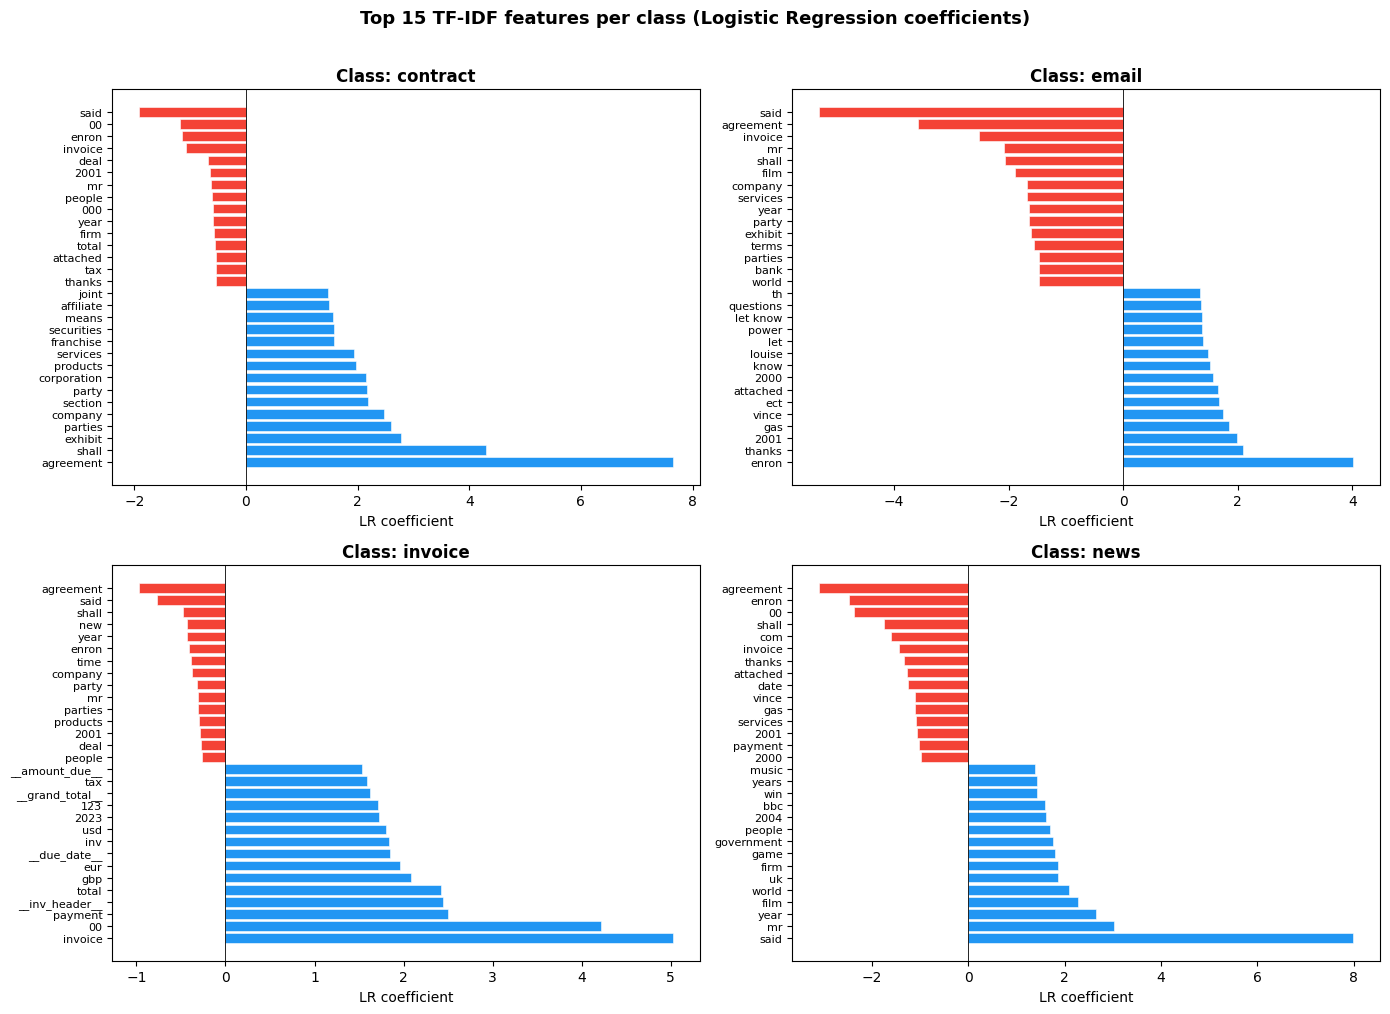

In [54]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = np.array(tfidf.get_feature_names_out())
classes = lr_model.classes_
n_top = 15

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Top 15 TF-IDF features per class (Logistic Regression coefficients)',
             fontsize=13, fontweight='bold', y=1.01)

for ax, cls in zip(axes.ravel(), classes):
    cls_idx = list(classes).index(cls)
    coef = lr_model.coef_[cls_idx]
    top_pos = np.argsort(coef)[-n_top:][::-1]
    top_neg = np.argsort(coef)[:n_top]
    idx = np.concatenate([top_pos, top_neg[::-1]])
    values = coef[idx]
    labels = feature_names[idx]
    colors = ['#2196F3' if v >= 0 else '#F44336' for v in values]
    bars = ax.barh(range(len(labels)), values, color=colors, edgecolor='white', linewidth=0.4)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.axvline(0, color='black', linewidth=0.6)
    ax.set_title(f'Class: {cls}', fontweight='bold')
    ax.set_xlabel('LR coefficient')

plt.tight_layout()
plt.show()


## Learning Curve

Shows how macro-F1 changes with training set size. A large gap between
training and validation scores indicates overfitting; both curves plateauing
early suggests more data would help. Particularly relevant given the
small invoice class (~64 samples).


/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/Users/denis/Desktop/stats-final-project/Document-Classification-and-Information-Extraction-/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings

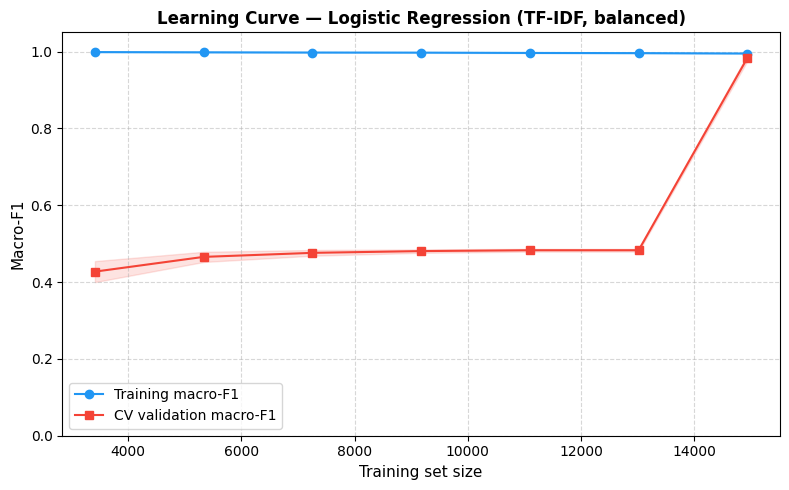


With 100% training data: train=0.9949, val=0.9833
With  10% training data: train=nan,  val=nan


In [55]:
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline

lc_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True, stop_words='english',
        ngram_range=(1, 2), min_df=3, max_features=20000
    )),
    ('clf', LogisticRegression(
        max_iter=1000, random_state=42,
        class_weight='balanced', n_jobs=-1
    )),
])

train_sizes, train_scores, val_scores = learning_curve(
    lc_pipe, X, y,
    cv=5,
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
    random_state=42,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#2196F3', label='Training macro-F1')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2196F3')
ax.plot(train_sizes, val_mean, 's-', color='#F44336', label='CV validation macro-F1')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#F44336')
ax.set_xlabel('Training set size', fontsize=11)
ax.set_ylabel('Macro-F1', fontsize=11)
ax.set_title('Learning Curve — Logistic Regression (TF-IDF, balanced)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'\nWith 100% training data: train={train_mean[-1]:.4f}, val={val_mean[-1]:.4f}')
print(f'With  10% training data: train={train_mean[0]:.4f},  val={val_mean[0]:.4f}')


In [56]:
import sys
sys.path.insert(0, str(Path("..").resolve()))
from src.preprocessing import clean_for_classifier

def classify_document(text: str) -> dict:
    """Classify raw document text.

    Returns a dict with:
        label       — predicted class (news / email / contract / invoice)
        confidence  — probability for the predicted class (0-1)
        proba       — full class probability dict
    """
    cleaned = clean_for_classifier(text)
    X = tfidf.transform([cleaned])
    label = lr_model.predict(X)[0]
    proba = dict(zip(lr_model.classes_, lr_model.predict_proba(X)[0].round(3)))
    return {
        "label":      label,
        "confidence": round(float(proba[label]), 3),
        "proba":      proba,
    }

## Save model artifacts

Persist the fitted TF-IDF vectorizer and the best classifier (Logistic Regression) so the demo pipeline (`src/service.py`) can load them without re-running training.

In [57]:
import joblib
from pathlib import Path

models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

# ── Select the best model by test macro-F1 ──────────────────────────────────
# Also evaluate the tuned GridSearch models on the test set
y_pred_gs_lr  = gs_lr.predict(X_test)
y_pred_gs_svm = gs_svm.predict(X_test)

candidates = {
    'Naive Bayes':         (nb_model,          tfidf, y_test_pred_nb),
    'Linear SVM':          (svm_model,         tfidf, y_test_pred_svm),
    'Logistic Regression': (lr_model,          tfidf, y_test_pred_lr),
    'Random Forest':       (rf_model,          tfidf, y_test_pred_rf),
    'Tuned LR (GS)':       (gs_lr,             None,  y_pred_gs_lr),
    'Tuned SVM (GS)':      (gs_svm,            None,  y_pred_gs_svm),
}

scores = {
    name: f1_score(y_test, preds, average='macro')
    for name, (_, _, preds) in candidates.items()
}
print('Test macro-F1 per candidate:')
for name, score in sorted(scores.items(), key=lambda x: -x[1]):
    print(f'  {name:<28} {score:.4f}')

best_name = max(scores, key=scores.get)
best_model, best_tfidf, _ = candidates[best_name]
print(f'\nSelected: {best_name} (test macro-F1 = {scores[best_name]:.4f})')

# ── Save ────────────────────────────────────────────────────────────────────
# GridSearch pipelines include their own TF-IDF; standalone models use the
# shared `tfidf` fitted on X_train.
if best_tfidf is not None:
    joblib.dump(best_tfidf,  models_dir / 'tfidf_vectorizer.joblib')
    joblib.dump(best_model,  models_dir / 'lr_classifier.joblib')
    print('Saved: standalone tfidf + classifier')
else:
    # GridSearch pipeline — service.py uses tfidf.transform + clf.predict
    # so we unwrap the pipeline components
    joblib.dump(best_model.best_estimator_.named_steps['tfidf'], models_dir / 'tfidf_vectorizer.joblib')
    joblib.dump(best_model.best_estimator_.named_steps['clf'],   models_dir / 'lr_classifier.joblib')
    print('Saved: tuned pipeline components (tfidf + clf)')

print(f'  {models_dir / "tfidf_vectorizer.joblib"}')
print(f'  {models_dir / "lr_classifier.joblib"}')


Test macro-F1 per candidate:
  Linear SVM                   0.9953
  Tuned SVM (GS)               0.9948
  Tuned LR (GS)                0.9940
  Logistic Regression          0.9935
  Random Forest                0.9912
  Naive Bayes                  0.9842

Selected: Linear SVM (test macro-F1 = 0.9953)
Saved: standalone tfidf + classifier
  ../models/tfidf_vectorizer.joblib
  ../models/lr_classifier.joblib
